# EDA & Visualizations

Exploring the merged rent + crime data, and saving the charts to `../images/` for the findings notebook.

## Step 1: Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# I want the graphs to use specific colors
plt.style.use("../styles/chance.mplstyle")
cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
FOAM = cycle[4]
LOVE = cycle[2]

# confirming the images folder exists
IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(exist_ok=True)

## Step 2: Load the Merged Dataset

In [27]:
df = pd.read_csv("../data/processed/housing_csi_merged_2020_2024.csv")
print("DF:",df.shape)
df.head()

DF: (85, 21)


,centre,vacancy_rental_condo,vacancy_rms,rent_rental_condo,rent_rms,universe_rental_condo,universe_rms,pct_condo_in_rental,year,csi_total,...,clearance_rate_nonviolent,csi_total_pct_change,csi_nonviolent_pct_change,clearance_rate_nonviolent_pct_change,csi_violent_pct_change,clearance_rate_violent_pct_change,clearance_rate_pct_change,csi_violent,clearance_rate_violent,clearance_rate
0,Calgary CMA,4.9,6.6,1596.0,1323,26520,41995,37.2,2020,79.96,...,22.06,-15.02,-17.52,0.41,-7.16,8.35,5.51,79.64,47.24,28.70
1,Calgary CMA,4.2,5.1,1524.0,1355,28384,44723,38.8,2021,72.78,...,23.42,-8.98,-13.92,6.17,5.96,-5.91,5.71,84.39,44.45,30.34
2,Calgary CMA,1.8,2.7,1648.0,1466,29003,48285,38.6,2022,77.48,...,23.70,6.46,11.40,1.20,-3.63,6.59,1.38,81.33,47.38,30.76
3,Calgary CMA,1.0,1.4,1819.0,1695,29373,51295,38.4,2023,72.66,...,27.02,-6.22,-10.73,14.01,4.39,-3.36,8.06,84.90,45.79,33.24
4,Calgary CMA,1.3,4.8,1970.0,1882,28844,56441,36.3,2024,63.29,...,27.22,-12.90,-15.71,0.74,-7.21,7.62,5.32,78.78,49.28,35.01


## Step 3: Rent vs CSI Over Time (National Average)

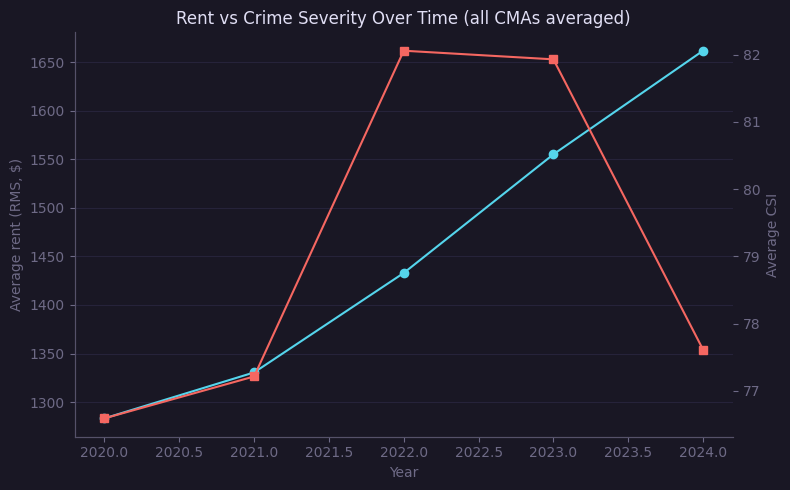

In [28]:
yearly = df.groupby("year")[["rent_rms", "csi_total"]].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(yearly["year"], yearly["rent_rms"], color=FOAM, marker="o", label="avg rent")
ax2.plot(yearly["year"], yearly["csi_total"], color=LOVE, marker="s", label="avg csi")
ax2.grid(False)

ax1.set_xlabel("Year")
ax1.set_ylabel("Average rent (RMS, $)")
ax2.set_ylabel("Average CSI")
ax1.set_title("Rent vs Crime Severity Over Time (all CMAs averaged)")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "national_rent_vs_csi_trend.png", dpi=150)
plt.show()

**Advantage:** simplest possible view, one line each, easy to read at a glance. Shows the overall national direction year to year.
**Limitation:** averaging all 17 cities together hides every bit of city-level variation -- a city that's getting more expensive and safer is indistinguishable from one doing the opposite once everything's pooled.

## Step 4: Rent vs CSI, City by City (Most Recent Year)
This really targets my initial question: 
**Do cities with lower crime actually have higher rent?**

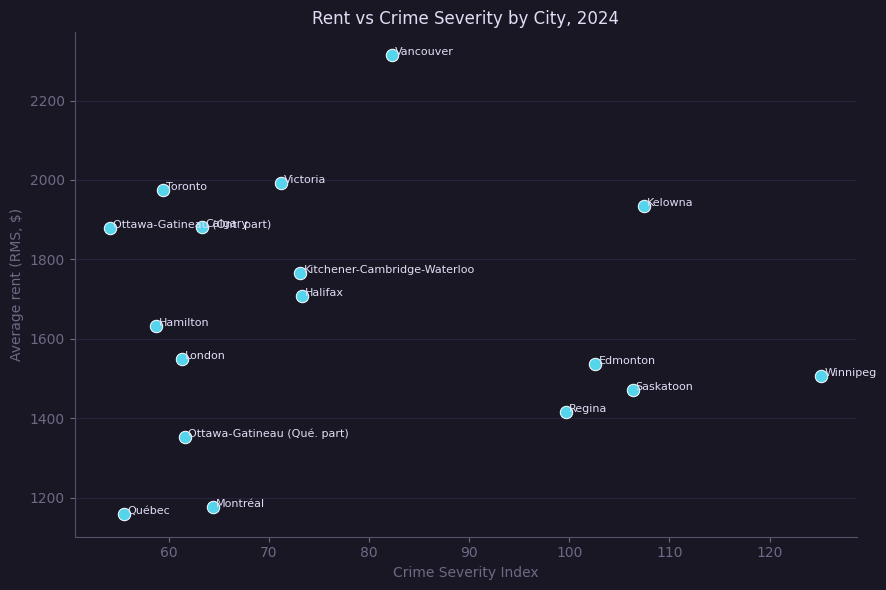

In [29]:
latest_year = df["year"].max()
latest = df[df["year"] == latest_year]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=latest, x="csi_total", y="rent_rms", s=80, color=FOAM)

for _, row in latest.iterrows():
    plt.text(row["csi_total"] + 0.3, row["rent_rms"], row["centre"].replace(" CMA", ""), fontsize=8)

plt.xlabel("Crime Severity Index")
plt.ylabel("Average rent (RMS, $)")
plt.title(f"Rent vs Crime Severity by City, {latest_year}")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "city_rent_vs_csi_latest_year.png", dpi=150)
plt.show()

**Advantage:** Directly compares cities against each other. Every city shows up as its own point, so nothing gets averaged away.

**Limitation:** This visualization only represents 2024. This could be an unusual year for that city specifically, and this view can't ascertain whether safety drives rent or these are just both correlated with something else about the city, such as size, region, or other desirable advantages.

## Step 5: Rent vs CSI Within Each City, Across All 5 Years
The first 2 visualizations either pool every city together or freeze on a single year, but neither one can tell me whether rent and crime actually move together within a given city over time. This visualization checks the correlation of cities' rent and CSI values across 2020-2024.

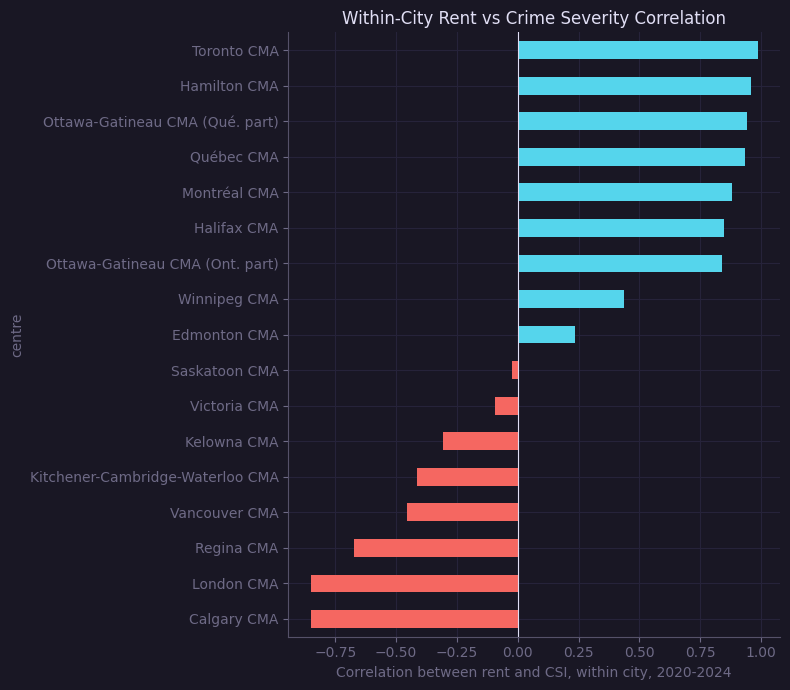

centre
Calgary CMA                        -0.851032
London CMA                         -0.850006
Regina CMA                         -0.673299
Vancouver CMA                      -0.454788
Kitchener-Cambridge-Waterloo CMA   -0.415817
Kelowna CMA                        -0.309195
Victoria CMA                       -0.095453
Saskatoon CMA                      -0.024526
Edmonton CMA                        0.236732
Winnipeg CMA                        0.434937
Ottawa-Gatineau CMA (Ont. part)     0.839420
Halifax CMA                         0.846787
Montréal CMA                        0.879023
Québec CMA                          0.933940
Ottawa-Gatineau CMA (Qué. part)     0.941188
Hamilton CMA                        0.956630
Toronto CMA                         0.985559
dtype: float64

In [30]:
per_centre_corr = (
    df.groupby("centre")
      .apply(lambda g: g["rent_rms"].corr(g["csi_total"]), include_groups=False)
      .sort_values()
)

colors = [LOVE if v < 0 else FOAM for v in per_centre_corr]

plt.figure(figsize=(8, 7))
per_centre_corr.plot(kind="barh", color=colors)
plt.axvline(0, color="#e0def4", linewidth=0.8)
plt.xlabel("Correlation between rent and CSI, within city, 2020-2024")
plt.title("Within-City Rent vs Crime Severity Correlation")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "within_city_correlation.png", dpi=150)
plt.show()

per_centre_corr

**Advantage:** Controls for whatever makes cities different from each other (size, region, base cost of living) since each city is only being compared to itself over time. This is the closest thing here to actually testing whether safety and rent move together, rather than just both happening to be higher or lower in the same cities.
**Limitation:** Only 5 years of data points per city, so each individual correlation is fragile. One unusual year for a city can swing its number a lot. The wide spread across cities (some strongly negative, some strongly positive) also means there's no single consistent within-city relationship to report. It looks different city by city.

## Step 6: Save the Per-City Correlations
Writing to disk so findings and the dashboard can read this directly instead of recomputing it.

In [31]:
per_centre_corr.rename("rent_csi_correlation").reset_index().to_csv(
    "../data/processed/per_centre_corr_2020_2024.csv", index=False
)
print("Saved per-city correlations!")

Saved per-city correlations!
